In [1]:
import sys
import os

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))

# Add parent directory to sys.path
sys.path.append(parent_dir)

print(parent_dir)


/home/adam/Documents/dev/gradual-aacbr/examples



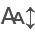

In [2]:
import torch
import torch.optim as optim
from itables import init_notebook_mode, show
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import importlib
from ray import tune

import deeparguing.gradual_aacbr as gradual_aacbr
import deeparguing.semantics.relu_semantics as rs
import deeparguing.base_scores.feature_weighted_base_score as fwbs
import deeparguing.casebase_edge_weights.feature_weighted_partial_order as fwpo
import deeparguing.irrelevance_edge_weights.regular_irrelevance as ri

from deeparguing.train import static_train_model, evaluate_model, cluster_data
from deeparguing.tune import tune_model, objective
from deeparguing.regulariser import sparsity_regulariser, community_preservation_regulariser, connectivity_regulariser, feature_smoothness_regulariser, regularise

from helper import load_glioma, split_data, normalise_input



init_notebook_mode(all_interactive=True)

In [3]:
def reload_imports():
    importlib.reload(gradual_aacbr)
    importlib.reload(rs)
    importlib.reload(fwbs)
    importlib.reload(fwpo)
    importlib.reload(ri)

reload_imports()

In [4]:
SEED = 42

## Data Set

In [5]:
X, y = load_glioma()
show(X)
show(y)

In [6]:
all_y = np.unique(y, axis=0)
show(all_y)

## Train Model

### Split into Training, Validation and Test

In [7]:
train_full, train, val, test = split_data(X, y, SEED)

print(f"Test Size:  {len(test['X'])}")
print(f"Train Size:  {len(train['X'])}")
print(f"Validation Size:  {len(val['X'])}")

Test Size:  168
Train Size:  536
Validation Size:  135


### Cluster dataset

In [8]:
X_centroids, y_centroids = cluster_data(train["X"], train["y"], lambda group_size: 20)

20 clusters for [0. 1.]
20 clusters for [1. 0.]


In [9]:
show(X_centroids)

In [10]:
X_centroids = torch.tensor(X_centroids, dtype=torch.float32)
y_centroids = torch.tensor(y_centroids, dtype=torch.float32)

### Convert to Torch

In [11]:
X_train_full, y_train_full = torch.tensor(train_full["X"]), torch.tensor(train_full["y"], dtype=torch.float32)
X_train, y_train = torch.tensor(train["X"]), torch.tensor(train["y"], dtype=torch.float32)
X_val, y_val = torch.tensor(val["X"]), torch.tensor(val["y"], dtype=torch.float32)
X_test, y_test = torch.tensor(test["X"]), torch.tensor(test["y"], dtype=torch.float32)

### Normalize dataset

In [12]:
train_mean = X_train.mean(dim=0)
train_std = X_train.std(dim=0)

X_train = normalise_input(X_train, train_mean, train_std)
X_centroids = normalise_input(X_centroids, train_mean, train_std)
X_val = normalise_input(X_val, train_mean, train_std)
X_test = normalise_input(X_test, train_mean, train_std)



In [13]:
show(X_train.cpu().numpy())

### Train Model

In [14]:
DEFAULT_CASE = X_train.mean(axis=0)

X_DEFAULTS = DEFAULT_CASE.tile(len(all_y), 1)
Y_DEFAULTS = torch.tensor(all_y)


In [15]:
MAX_ITERS = 20
EPOCHS = 3000
USE_SYMMETRIC_ATTACKS = False
LR = 0.027724410326258685
MOMENTUM = 0.9
SHARPNESS = 0.6052368105626966
# USE_BLOCKERS = True
USE_BLOCKERS = False
# want it to work regardless of this?
import random
# seed = random.randint(0, 100000)
seed = 78741
print(seed)
torch.manual_seed(seed)



78741


In [16]:
reload_imports()

no_features = X_train.shape[-1]
semantics = rs.ReluSemantics(max_iters=MAX_ITERS, epsilon=0)
partial_order = fwpo.FeatureWeightedPartialOrder(no_features, sharpness=SHARPNESS)
irrelevance = ri.RegularIrrelevance(partial_order)
base_score = fwbs.FeatureWeightedBaseScore(no_features)


alpha = 5 * 1e-4

# regulariser = lambda model: alpha * sparsity_regulariser(model)
# regulariser = lambda model: alpha * connectivity_regulariser(model)
# regulariser = lambda model: alpha * community_preservation_regulariser(model)
# regulariser = lambda model: alpha * (sparsity_regulariser(model) + connectivity_regulariser(model) + community_preservation_regulariser(model))
# regulariser = lambda model: 0

regulariser = lambda model: regularise(model, [
    [sparsity_regulariser, alpha], 
    [connectivity_regulariser, alpha], 
    [community_preservation_regulariser, alpha],
    [feature_smoothness_regulariser, alpha]
    ])

model = gradual_aacbr.GradualAACBR(semantics, 
                                base_score,
                                irrelevance,
                                partial_order)

criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM)

Accuracy, Precision, Recall, F1
(0.6962962962962963, np.float64(0.34814814814814815), np.float64(0.5), np.float64(0.4104803493449782))


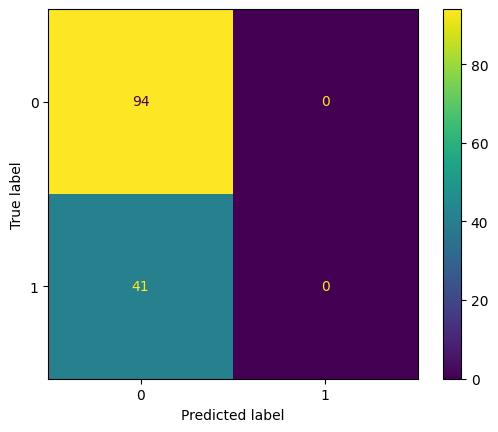

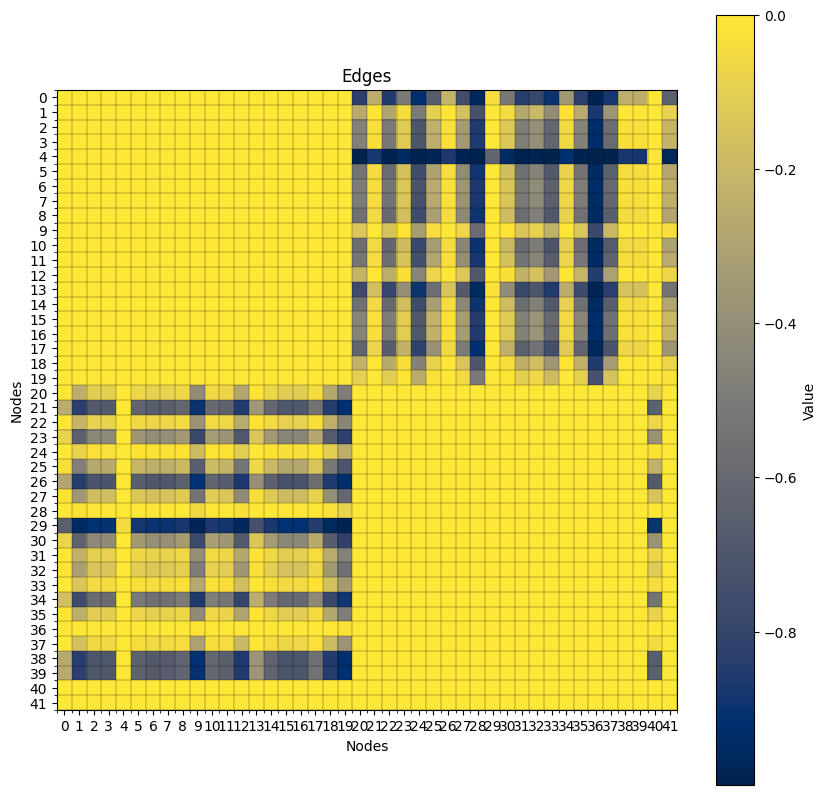

(0.6962962962962963,
 np.float64(0.34814814814814815),
 np.float64(0.5),
 np.float64(0.4104803493449782))

In [17]:
reload_imports()
evaluate_model(model, X_centroids, y_centroids, X_DEFAULTS, Y_DEFAULTS, X_val, y_val, show_confusion=True, use_blockers=USE_BLOCKERS,  print_matrix=True, print_compute_graph=True, print_graph = False )
# model.plot_casebase_edge_weights_parameters()
# model.plot_base_score_parameters()

Epoch 3000, Loss: 0.0023: 100%|██████████| 3000/3000 [00:29<00:00, 100.34it/s]


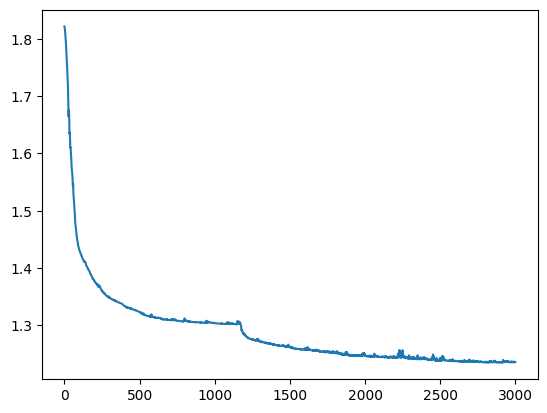

In [18]:
static_train_model(model, X_centroids, y_centroids, 
                   X_DEFAULTS, Y_DEFAULTS, optimizer, 
                   criterion, EPOCHS, X_new_cases=X_train, y_new_cases=y_train, 
                   use_symmetric_attacks=False, use_blockers=USE_BLOCKERS, 
                   plot_loss_curve=True,
                   regularise_graph=regulariser
                   )

Accuracy, Precision, Recall, F1
(0.8296296296296296, np.float64(0.8116666666666668), np.float64(0.8639076284379865), np.float64(0.8180912765832796))


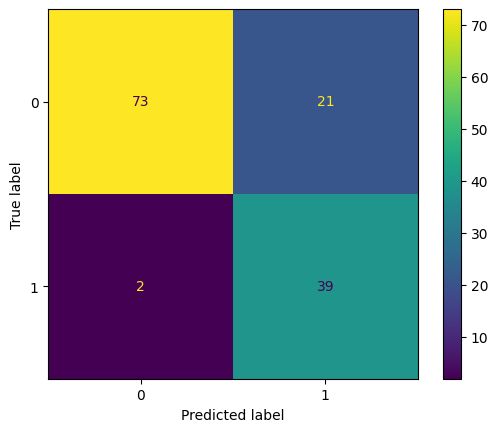

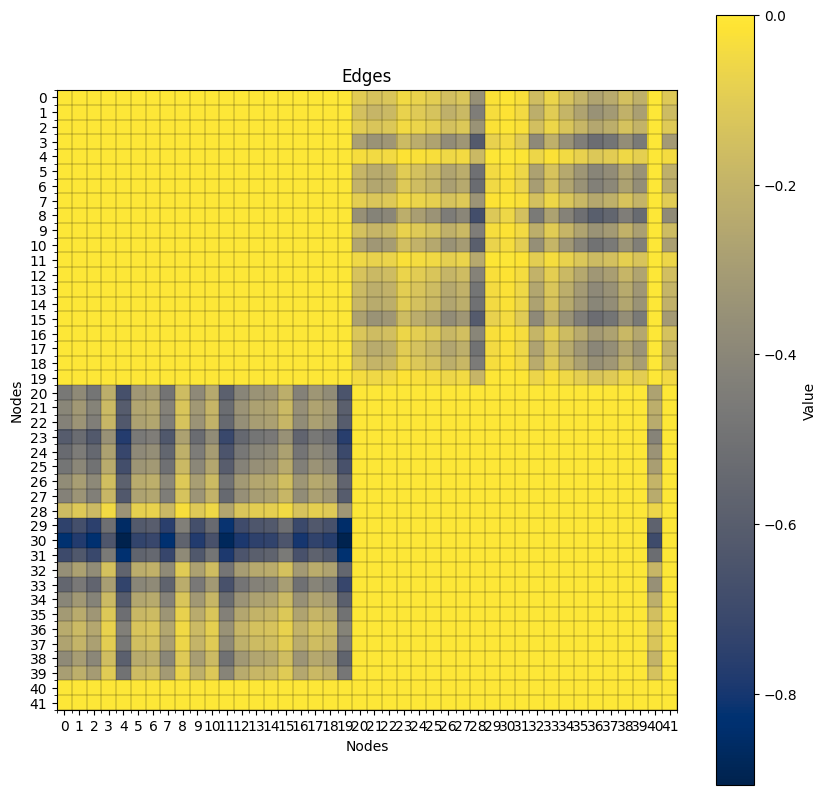

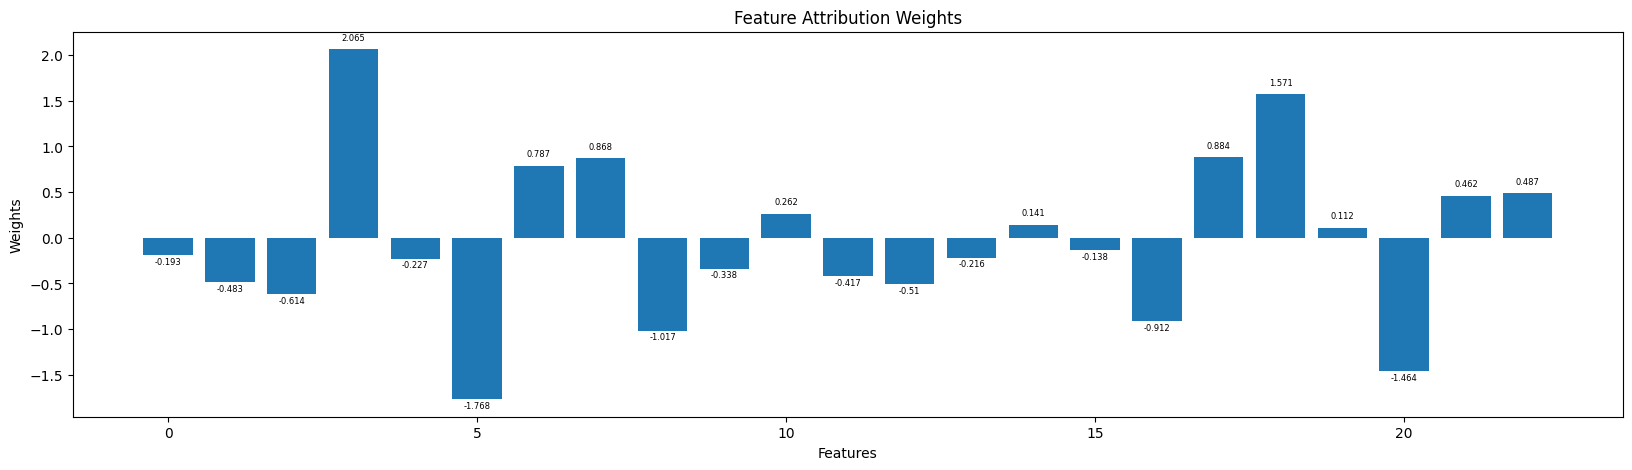

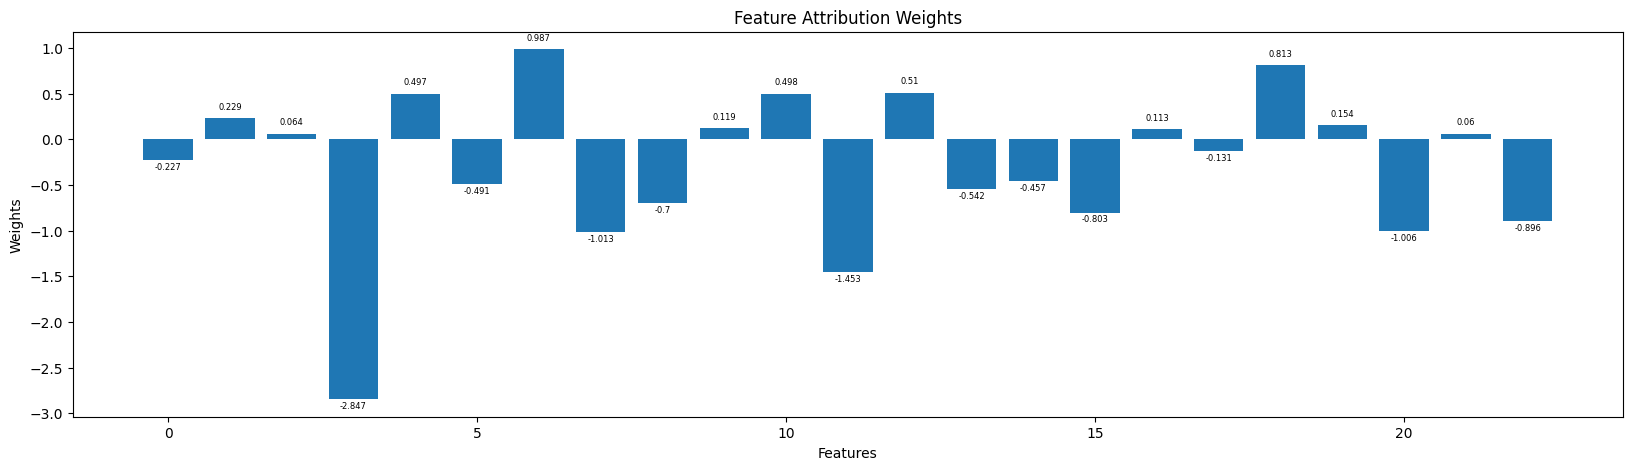

In [21]:
reload_imports()
with torch.no_grad():
    evaluate_model(model, X_centroids, y_centroids, X_DEFAULTS, Y_DEFAULTS, X_val, y_val, show_confusion=True, use_blockers=USE_BLOCKERS,  print_matrix=True, print_compute_graph=False, print_graph=False  )

model.plot_casebase_edge_weights_parameters()
model.plot_base_score_parameters()

In [20]:
assert(False)

AssertionError: 

Accuracy, Precision, Recall, F1
(0.8452380952380952, np.float64(0.8501498501498501), np.float64(0.8489546294979378), np.float64(0.8452161587526577))


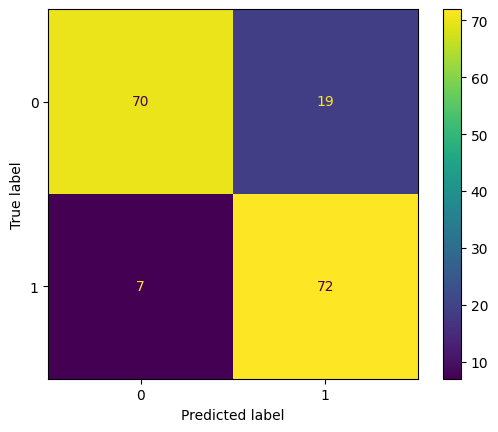

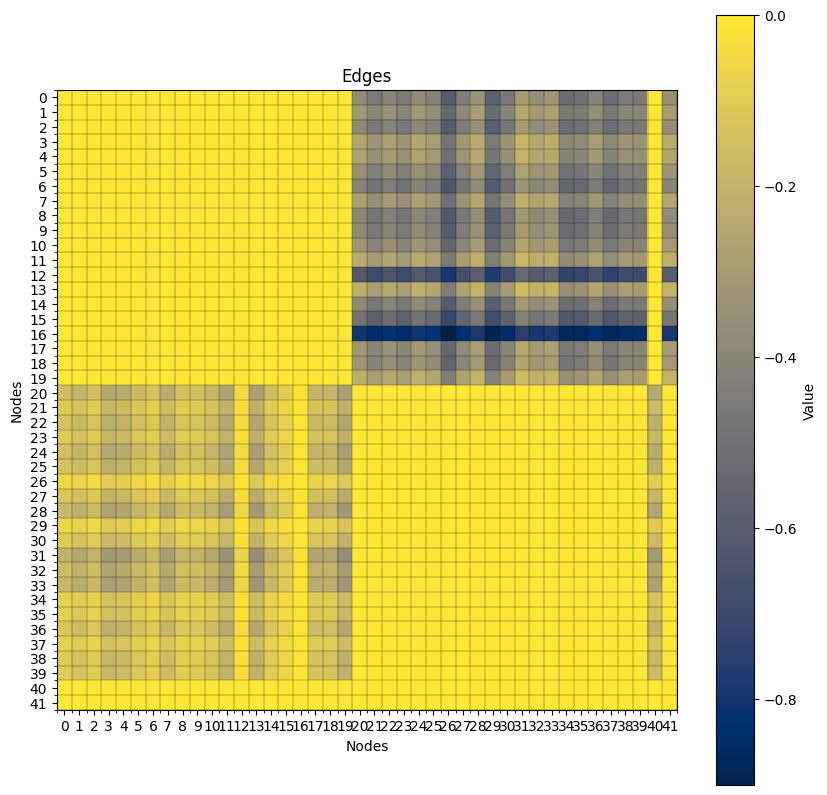

(0.8452380952380952,
 np.float64(0.8501498501498501),
 np.float64(0.8489546294979378),
 np.float64(0.8452161587526577))

In [ ]:

evaluate_model(model, X_centroids, y_centroids, X_DEFAULTS, Y_DEFAULTS, X_test, y_test, show_confusion=True, use_blockers=USE_BLOCKERS,  print_matrix=True, print_compute_graph=True, print_graph = False )

### Hyperparameter Tuning

In [ ]:
search_space = {
    "train": static_train_model,
    # "use_blockers": tune.choice([True, False]),
    "use_blockers": True,
    "no_iters": tune.choice([15, 20, 25]),
    "epochs": tune.choice([250, 750, 1500, 3000]),
    "lr": tune.loguniform(1e-4, 1e-1),
    "momentum": tune.loguniform(1e-4, 1e-1),
    "sharpness": tune.loguniform(1e-1, 1e1),
    "use_symmetric_attacks": tune.choice([True, False]),
    "semantics": tune.sample_from(lambda config: rs.ReluSemantics(max_iters=config["no_iters"], epsilon=0)),
    "partial_order": tune.sample_from(lambda config: fwpo.FeatureWeightedPartialOrder(no_features, sharpness=config["sharpness"])),
    "irrelevance": tune.sample_from(lambda config: ri.RegularIrrelevance(config["partial_order"])),
    "base_score": fwbs.FeatureWeightedBaseScore(no_features),
    "alpha": tune.loguniform(1e-6, 1e-1),
    "beta": tune.loguniform(1e-6, 1e-1),
    "gamma": tune.loguniform(1e-6, 1e-1),
    "lambda": tune.loguniform(1e-6, 1e-1),
    "regulariser": tune.sample_from(lambda config: (lambda model: regularise(model, [
                    [sparsity_regulariser, config["alpha"]], 
                    [connectivity_regulariser, config["beta"]], 
                    [community_preservation_regulariser, config["gamma"]],
                    [feature_smoothness_regulariser, config["lambda"]]
    ]))),
}


In [ ]:
best_results = tune_model(search_space, X_centroids, y_centroids, X_DEFAULTS, Y_DEFAULTS, 
                          X_train, y_train, X_val, y_val, 
                          metric="f1", num_samples=10, disable_tqdm=True)


In [ ]:
print(best_results)


In [ ]:
# best_results = {'no_iters': 20, 'epochs': 3000, 'lr': 0.027724410326258685, 'sharpness': 0.6052368105626966, "momentum": 0.9, 'seed': 36, 'symmetric_attacks': False}


partial_order = fwpo.FeatureWeightedPartialOrder(no_features, sharpness=best_results["sharpness"])
irrelevance = ri.RegularIrrelevance(partial_order)
base_score = fwbs.FeatureWeightedBaseScore(no_features)

regulariser = lambda model: regularise(model, [
                    [sparsity_regulariser, best_results["alpha"]], 
                    [connectivity_regulariser, best_results["beta"]], 
                    [community_preservation_regulariser, best_results["gamma"]]
    ])

params = {
    "train": static_train_model,
    "use_blockers": best_results["use_blockers"],
    "epochs": best_results["epochs"],
    "lr": best_results["lr"],
    "momentum": best_results["momentum"],
    "use_symmetric_attacks": best_results["use_symmetric_attacks"],
    "semantics": semantics,
    "partial_order": partial_order,
    "irrelevance": irrelevance,
    "base_score": base_score,
    "regulariser": regulariser,
}



objective(params, 
          X_casebase=X_centroids, 
          y_casebase=y_centroids, 
          X_default=X_DEFAULTS, 
          y_default=Y_DEFAULTS, 
          X_train_new_cases=X_train, 
          y_train_new_cases=y_train, 
          X_eval_new_cases=X_val, 
          y_eval_new_cases=y_val, 
          show_confusion=True, 
          plot_loss_curve = True)


### Test Set

In [ ]:
reload_imports()
objective(params, X_centroids, y_centroids, X_DEFAULTS, Y_DEFAULTS, X_train_full, y_train_full, X_test, y_test, show_confusion=True, plot_loss_curve = True)